In [32]:
#Name: Alexandro Galvez-Vega
#Team: Alexandro Galvez-Vega and Victor Neyra
#Class: CAP 5625-042 Computational Foundations Of AI
#Professor: Michael DeGiorgio

In [33]:
#Starting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image

In [34]:
filename = "Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)

#This dataframe is quickly split between the features that will be used for x

x_features_df = advertising_df.copy(deep = True)


#Our goal is to determine credit card balance which is separated into its own df here

y_features_df = x_features_df.pop("Balance") 

In [35]:

#Converting the categorical columns from the dataset
x_features_df = pd.get_dummies(x_features_df, columns = ["Gender"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Married"], drop_first=True, dtype=int)

x_features_df = pd.get_dummies(x_features_df, columns = ["Student"], drop_first=True, dtype=int)

In [36]:
x_features_df.head()

,Income,Limit,Rating,Cards,Age,Education,Gender_Male,Married_Yes,Student_Yes
0,14.891,3606,283,2,34,11,1,1,0
1,106.025,6645,483,3,82,15,0,1,1
2,104.593,7075,514,4,71,11,1,0,0
3,148.924,9504,681,3,36,11,0,0,0
4,55.882,4897,357,2,68,16,1,1,0


In [37]:

#For the purposes of the assignment, we are using ridge regression
#which requires standardization of the data
y_standardized = y_features_df - y_features_df.mean()

#Here we are standardizing the numerical columns of the data set.
numerical_features = ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education']
X_standardized = x_features_df.copy()
X_standardized[numerical_features] = (x_features_df[numerical_features] - x_features_df[numerical_features].mean()) / x_features_df[numerical_features].std()






In [38]:
#We add a dummy 1 column for the future matrix math involving beta which will include a beta_0
# x_standardized_add1 = X_standardized.assign(dummy=1)
# moving_column = x_standardized_add1.pop("dummy") 
# x_standardized_add1.insert(0, "beta_0", moving_column)

x_standardized_add1 = X_standardized




#This time the starting learning rate is 10 ^ -5
learning_rate_alpha = 10 ** -5
tuning_parameter = 10 ** -2


k_fold = 5  

#We get the total number of observations involved
observations_N = len(X_standardized)

#We note the total number of features too
feature_total_p = len(x_standardized_add1.columns)

#The dataframes are converted to numpy arrays to allow for the matrix math that is going to be involved
X = x_standardized_add1.to_numpy()



y = y_standardized.to_numpy()

#This is also provided a1 and represents the bath based on the batch_size_n noted split
k_N_Splits = observations_N // k_fold 


#"Note, that a standardized coefficients are always in a range between -1 and +1"
#Random is used to give us a random initial beta, -1 and 1 are used as a range

#initial_beta = np.random.uniform(-1, 1, feature_total_p)
initial_beta = np.random.uniform(-1, 1, feature_total_p)


In [39]:
#This is redundant but I set beta to initial beta
#I wanted to have a variable specifically for the intial randomally set beta
intermediary_beta = initial_beta
#Beta refined will act as final beta
#This is also a little redundant but I want a clear variable for this as well

#Placeholder until final values are estbalished
vector_param_beta = initial_beta

#variable to keep track of all beta resuls for graphing
record_of_v_beta = []


#variable to keep track of the cost history for graphing
record_of_cost = []

#The iteration loop size is set to 20,000
# _ is used instead of commas for python
iter_loops = 100_000

In [41]:

random_reorder = np.random.permutation(observations_N)
cross_validation_account = []

for fold in range(k_fold):
    intermediary_beta = initial_beta.copy()


    beg_index = fold * k_N_Splits
    end_index = (fold + 1) * k_N_Splits
    beg_to_end_indexes = np.arange(beg_index, end_index)

    

    validation_unit = random_reorder[beg_to_end_indexes]
    X_validation_set = X[validation_unit]
    y_validation_set = y[validation_unit]

    X_training_set = np.delete(X, validation_unit, axis=0)
    y_training_set = np.delete(y, validation_unit, axis=0)


    for iter_c in range(iter_loops):

        #X transpose is needed for the equation
        X_training_transposed = np.transpose(X_training_set)
        #The math here can be found from a1
        update_pv_p1 = X_training_transposed.dot(y_training_set - X_training_set.dot(intermediary_beta))
        #update_pv_p2 = ((tuning_parameter * intermediary_beta) - update_pv_p1)
        update_pv_p2 = (update_pv_p1 - (tuning_parameter * intermediary_beta))
        intermediary_beta += 2 * learning_rate_alpha * update_pv_p2
    
    y_vaidation__set_predicted = X_validation_set.dot(intermediary_beta)

    validation_error = np.sum((y_validation_set - y_vaidation__set_predicted)**2) / len(y_validation_set)
    cross_validation_account.append(validation_error)
    print(validation_error)

cross_validation_error = np.mean(cross_validation_account)
print(cross_validation_error)








10493.045519647705
10142.126107833203
11800.985285509438
8663.57221565879
12642.507504632107
10748.447326656249


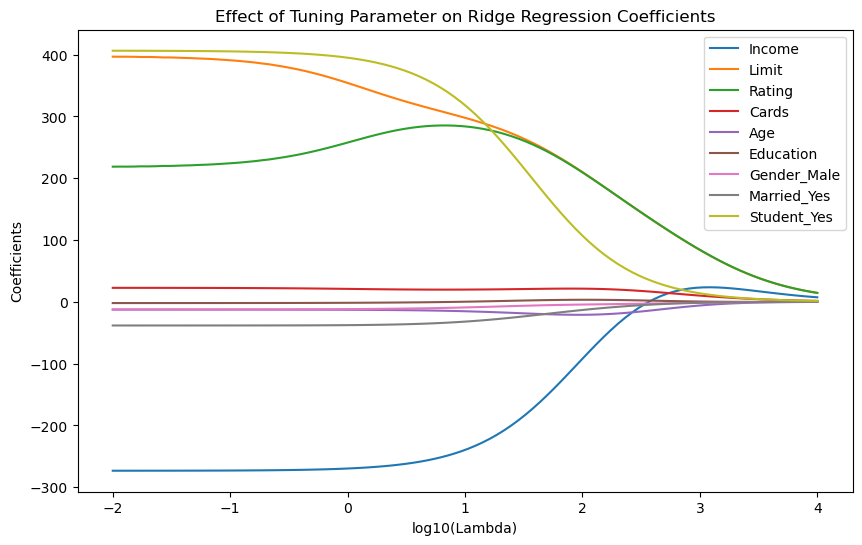

In [3]:
# Starting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

filename = r"C:\Users\victo\OneDrive\Documentos\DATA SCIENCE AND ANALYTICS\FULL 2024\Computational Foundations AI\Credit_N400_p9.csv"
advertising_df = pd.read_csv(filename)

# This dataframe is quickly split between the features that will be used for X
x_features_df = advertising_df.copy(deep=True)

# Our goal is to determine credit card balance which is separated into its own df here
y_features_df = x_features_df.pop("Balance")

# Converting the categorical columns from the dataset
x_features_df = pd.get_dummies(x_features_df, columns=["Gender"], drop_first=True, dtype=int)
x_features_df = pd.get_dummies(x_features_df, columns=["Married"], drop_first=True, dtype=int)
x_features_df = pd.get_dummies(x_features_df, columns=["Student"], drop_first=True, dtype=int)

# Standardizing the numerical columns of the data set
numerical_features = ['Income', 'Limit', 'Rating', 'Cards', 'Age', 'Education']
X_standardized = x_features_df.copy()
X_standardized[numerical_features] = (x_features_df[numerical_features] - x_features_df[numerical_features].mean()) / x_features_df[numerical_features].std()

# Assign X and y
X = X_standardized.to_numpy()
y = (y_features_df - y_features_df.mean()).to_numpy()

# Set parameters for learning rate and tuning
learning_rate_alpha = 10 ** -5
k_fold = 5  
observations_N = len(X_standardized)
feature_total_p = len(X_standardized.columns)

# Gradient descent iterations
iter_loops = 100_000
cross_validation_account = []

# Initialize the variable to store coefficients for different lambdas
lambda_values = np.logspace(-2, 4, 100)  # Lambda range from 0.01 to 10^4
coefficients = []  # To store coefficients for each lambda

# Ridge regression function for gradient descent
def ridge_regression(X, y, lambda_val, alpha=learning_rate_alpha, num_iterations=100000):
    beta = np.random.uniform(-1, 1, feature_total_p)  # Initialize beta
    for _ in range(num_iterations):
        X_transposed = X.T
        gradient = -2 * X_transposed.dot(y - X.dot(beta)) + 2 * lambda_val * beta
        beta -= alpha * gradient
    return beta

# Loop over each lambda value and calculate the coefficients
for lambda_val in lambda_values:
    final_beta = ridge_regression(X, y, lambda_val)  # Train on full data for final coefficients
    coefficients.append(final_beta)  # Store the final coefficients for this lambda

# Convert coefficients to a numpy array for easier manipulation
coefficients = np.array(coefficients)

# 1. Plot: Effect of Tuning Parameter on Ridge Regression Coefficients
plt.figure(figsize=(10, 6))
for i in range(coefficients.shape[1]):
    plt.plot(np.log10(lambda_values), coefficients[:, i], label=f'Feature {i+1}')
plt.xlabel('log10(Lambda)')
plt.ylabel('Coefficients')
plt.title('Effect of Tuning Parameter on Ridge Regression Coefficients')
plt.legend(x_features_df.columns)  # Use feature names as labels
plt.show()


In [7]:
# Initialize list to store cross-validation errors
cross_validation_errors = []  # This will store the CV errors for each lambda

# Perform k-fold cross-validation and calculate errors for each lambda value
for lambda_val in lambda_values:
    validation_errors = []  # To track errors for each fold
    
    # Shuffle the data for cross-validation
    random_reorder = np.random.permutation(observations_N)
    k_N_Splits = observations_N // k_fold
    
    for fold in range(k_fold):
        beg_index = fold * k_N_Splits
        end_index = (fold + 1) * k_N_Splits
        validation_unit = random_reorder[beg_index:end_index]
        
        X_validation_set = X[validation_unit]
        y_validation_set = y[validation_unit]
        
        X_training_set = np.delete(X, validation_unit, axis=0)
        y_training_set = np.delete(y, validation_unit, axis=0)
        
        # Train ridge regression model on the training set
        beta = ridge_regression(X_training_set, y_training_set, lambda_val)
        
        # Predict validation set
        y_pred_validation = X_validation_set.dot(beta)
        validation_error = np.sum((y_validation_set - y_pred_validation) ** 2) / len(y_validation_set)
        validation_errors.append(validation_error)
    
    # Store the mean error for this lambda value
    avg_validation_error = np.mean(validation_errors)
    cross_validation_errors.append(avg_validation_error)

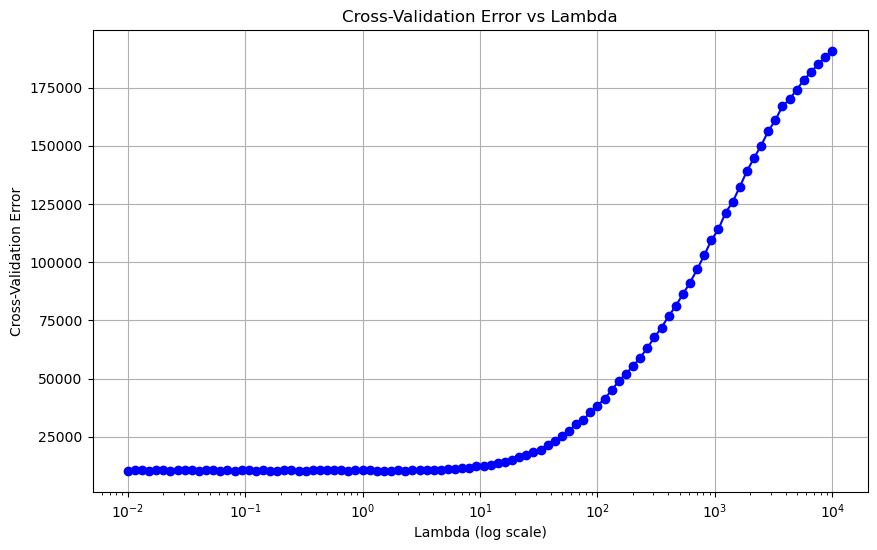

In [9]:
# Plot: Cross-Validation Error vs Lambda (Deliverable 2)
plt.figure(figsize=(10, 6))
plt.semilogx(lambda_values, cross_validation_errors, 'bo-')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Cross-Validation Error')
plt.title('Cross-Validation Error vs Lambda')
plt.grid(True)
plt.show()